## Task 1 — Data Loading, Merging & Deep Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
plt.style.use("ggplot")
pd.set_option('display.max_columns',None)

In [3]:
df=pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [5]:
df["Order Date"]=pd.to_datetime(df["Order Date"],format="%d/%m/%Y")
df["Ship Date"]=pd.to_datetime(df["Ship Date"],format="%d/%m/%Y")

In [6]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [7]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day

df["Day Name"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter

In [8]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"
df["Season"]=df["Month"].apply(get_season)

In [9]:
missing=df.isnull().sum()
missing=missing[missing>0]
missing

Postal Code    11
dtype: int64

In [10]:
duplicates=df.duplicated().sum()
print("Duplicates:",duplicates)

Duplicates: 0


In [11]:
df = df.drop_duplicates()

In [12]:
daily_sales=(
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [13]:
weekly_sales=(
    df.resample("W",on="Order Date")["Sales"]
    .sum()
    .reset_index()
)
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [14]:
monthly_sales=(
    df.resample("ME",on="Order Date")["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


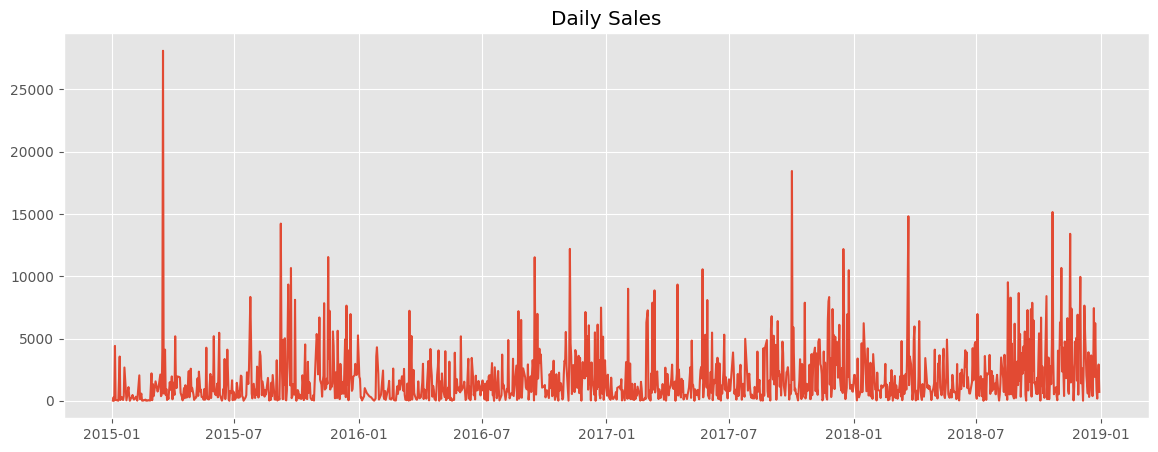

In [15]:
plt.figure(figsize=(14,5))

plt.plot(daily_sales["Order Date"],
         daily_sales["Sales"])

plt.title("Daily Sales")

plt.show()

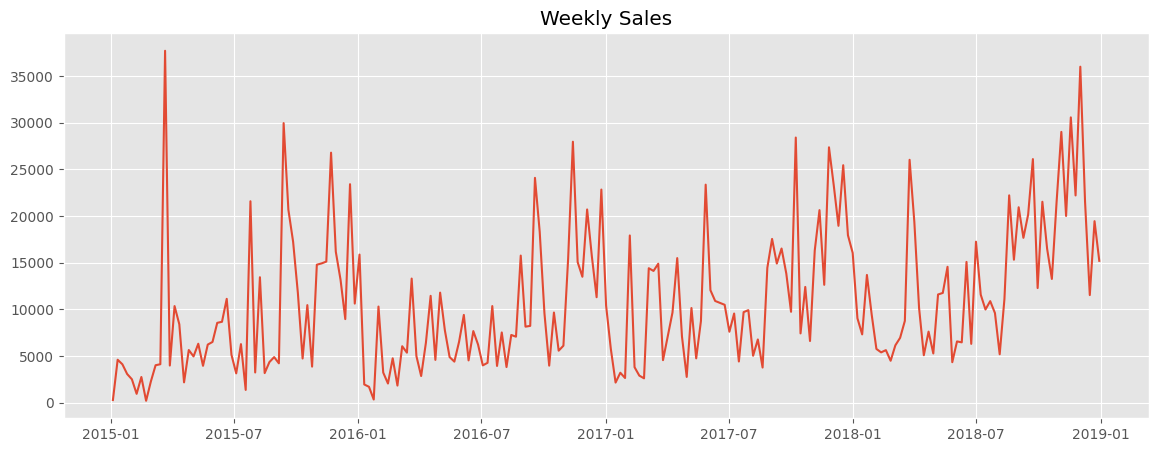

In [16]:
plt.figure(figsize=(14,5))

plt.plot(weekly_sales["Order Date"],
         weekly_sales["Sales"])

plt.title("Weekly Sales")

plt.show()

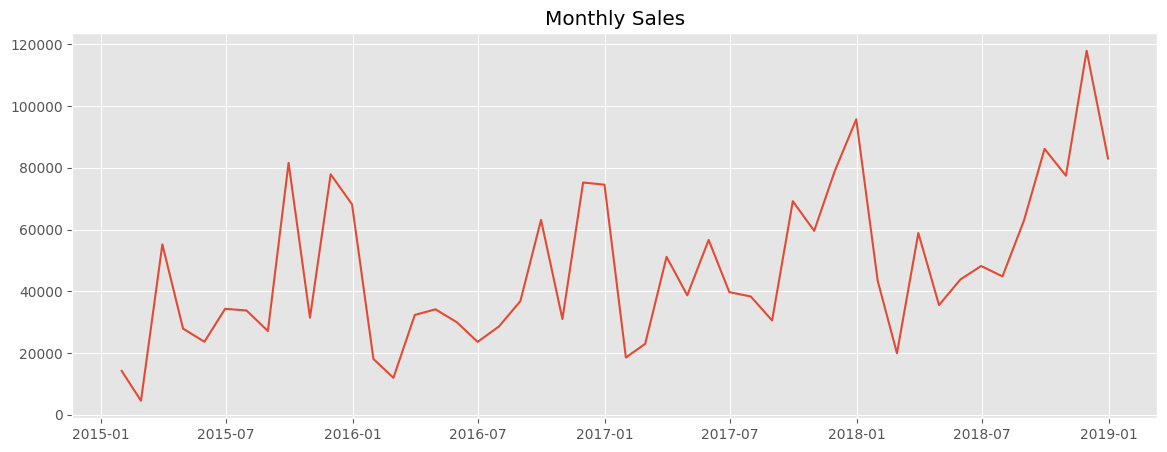

In [17]:
plt.figure(figsize=(14,5))

plt.plot(monthly_sales["Order Date"],
         monthly_sales["Sales"])

plt.title("Monthly Sales")

plt.show()

In [18]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [19]:
region_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq="ME"),
        "Region"
    ])["Sales"]
    .sum()
    .reset_index()
)
region_monthly.head()

,Order Date,Region,Sales
0,2015-01-31,Central,1533.966
1,2015-01-31,East,436.174
2,2015-01-31,South,9296.844
3,2015-01-31,West,2938.723
4,2015-02-28,Central,1233.174


In [20]:
region_stats = (
    region_monthly.groupby("Region")["Sales"]
    .agg(["mean","std"])
)

region_stats["CV"] = region_stats["std"]/region_stats["mean"]

region_stats.sort_values("CV")

,mean,std,CV
Region,,,
West,14796.243427,8099.099152,0.547375
Central,10263.477358,7095.130421,0.691299
South,8107.322062,6191.006547,0.763632
East,13948.306792,10694.236012,0.766705


In [21]:
df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

df["Shipping Days"].mean()

3.9611224489795918

In [22]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

print(shipping_region)

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


<Axes: xlabel='Month Name'>

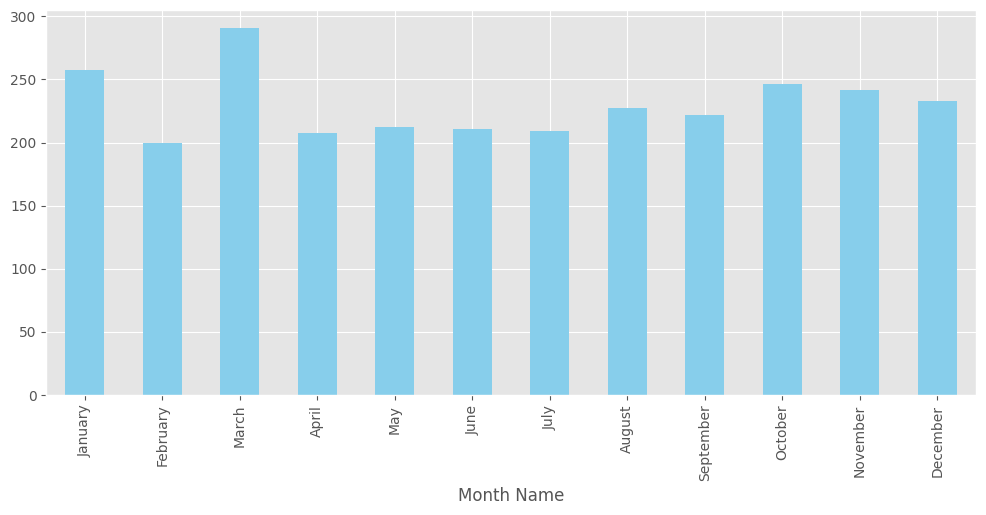

In [23]:
monthly_pattern = (
    df.groupby("Month Name")["Sales"]
      .mean()
      .reindex([
          "January",
          "February",
          "March",
          "April",
          "May",
          "June",
          "July",
          "August",
          "September",
          "October",
          "November",
          "December"
      ])
)
monthly_pattern.plot(kind="bar",figsize=(12,5),color="skyblue")

In [24]:
pivot = df.pivot_table(
    values="Sales",
    index="Month",
    columns="Year",
    aggfunc="sum"
)

pivot

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


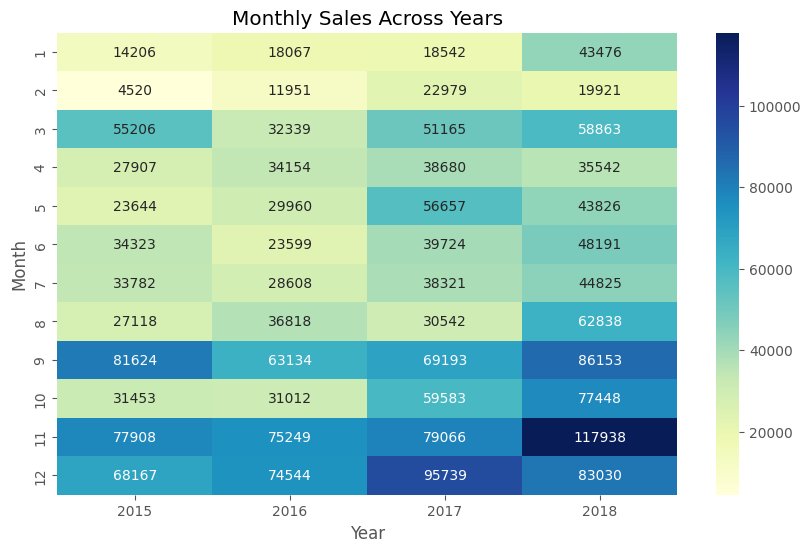

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Monthly Sales Across Years")

plt.show()

Question 1
Which Product Category Generates Highest Revenue?
Technology generated the highest total revenue, followed by Furniture and Office Supplies.

Question 2
Which Region Has the Most Consistent Sales Growth?
West

Question 3
What is the average time between Order Date and Ship Date — and does it vary by region?
~3.96 days
the average time does vary by region
Central Region takes the longest while east shows the fastest deliveries

Question 4
Do Certain Months Always Spike?
November and December consistently show elevated sales across multiple years, indicating strong seasonality likely associated with holiday shopping.

## Task 2 — Time Series Analysis & Decomposition

In [26]:
monthly_sales = (
    df.resample("M", on="Order Date")["Sales"]
      .sum()
)

monthly_sales.head()

C:\Users\KRISH\tmp\ipykernel_20332\884470942.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M", on="Order Date")["Sales"]


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

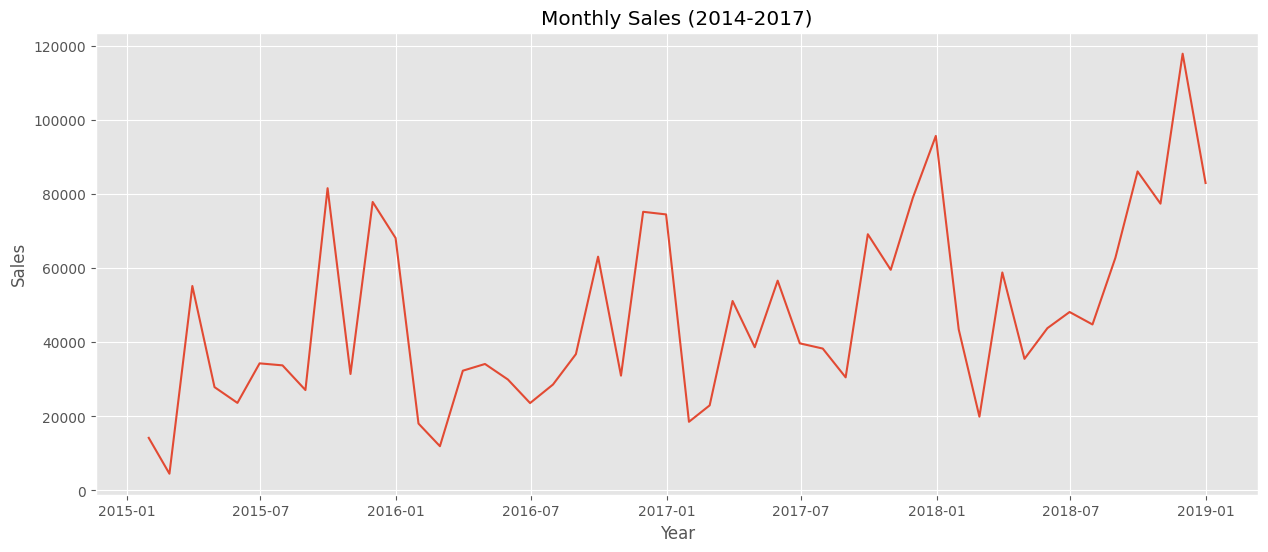

In [27]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales)

plt.title("Monthly Sales (2014-2017)")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [29]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

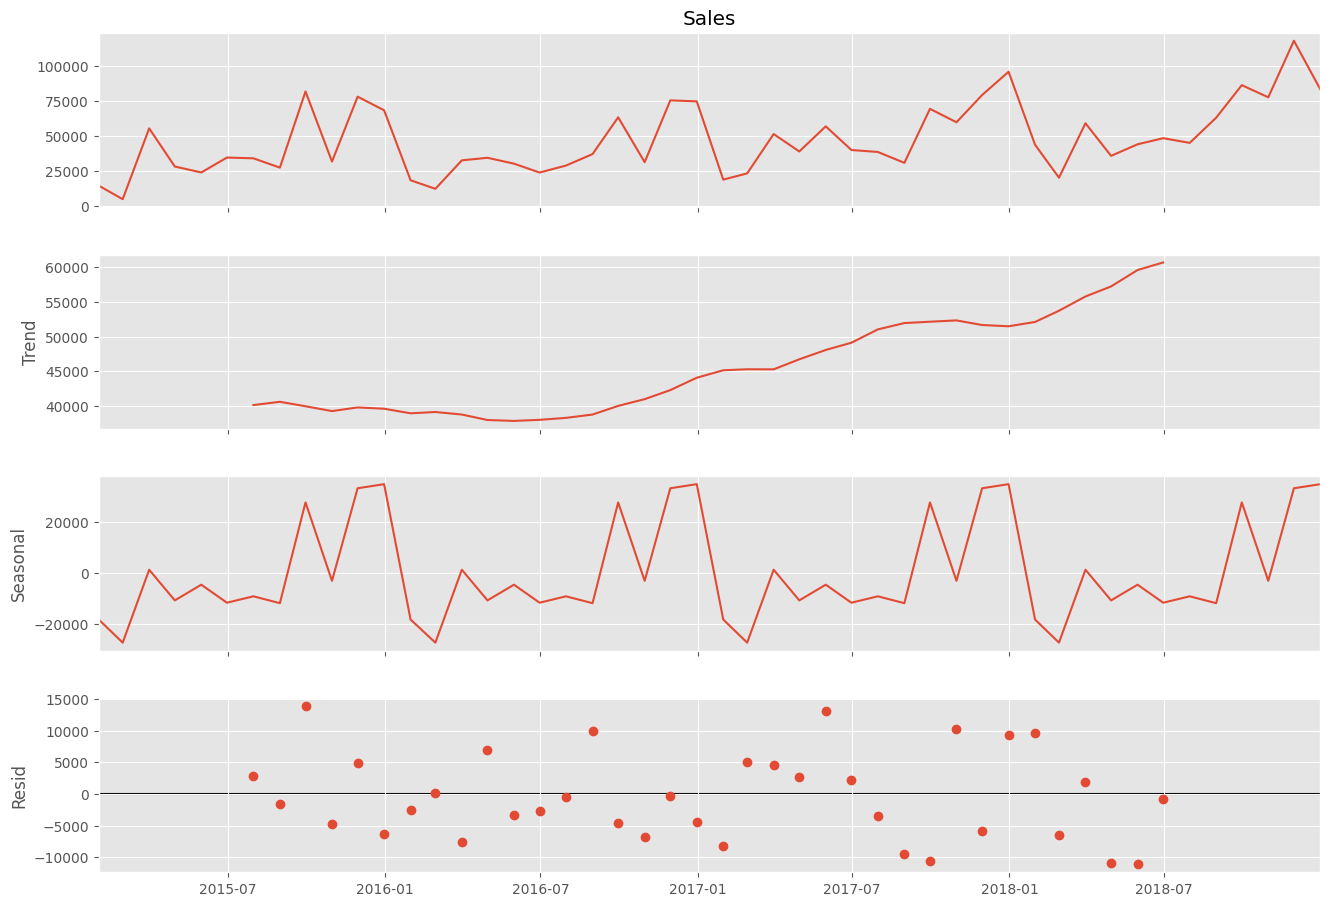

In [30]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

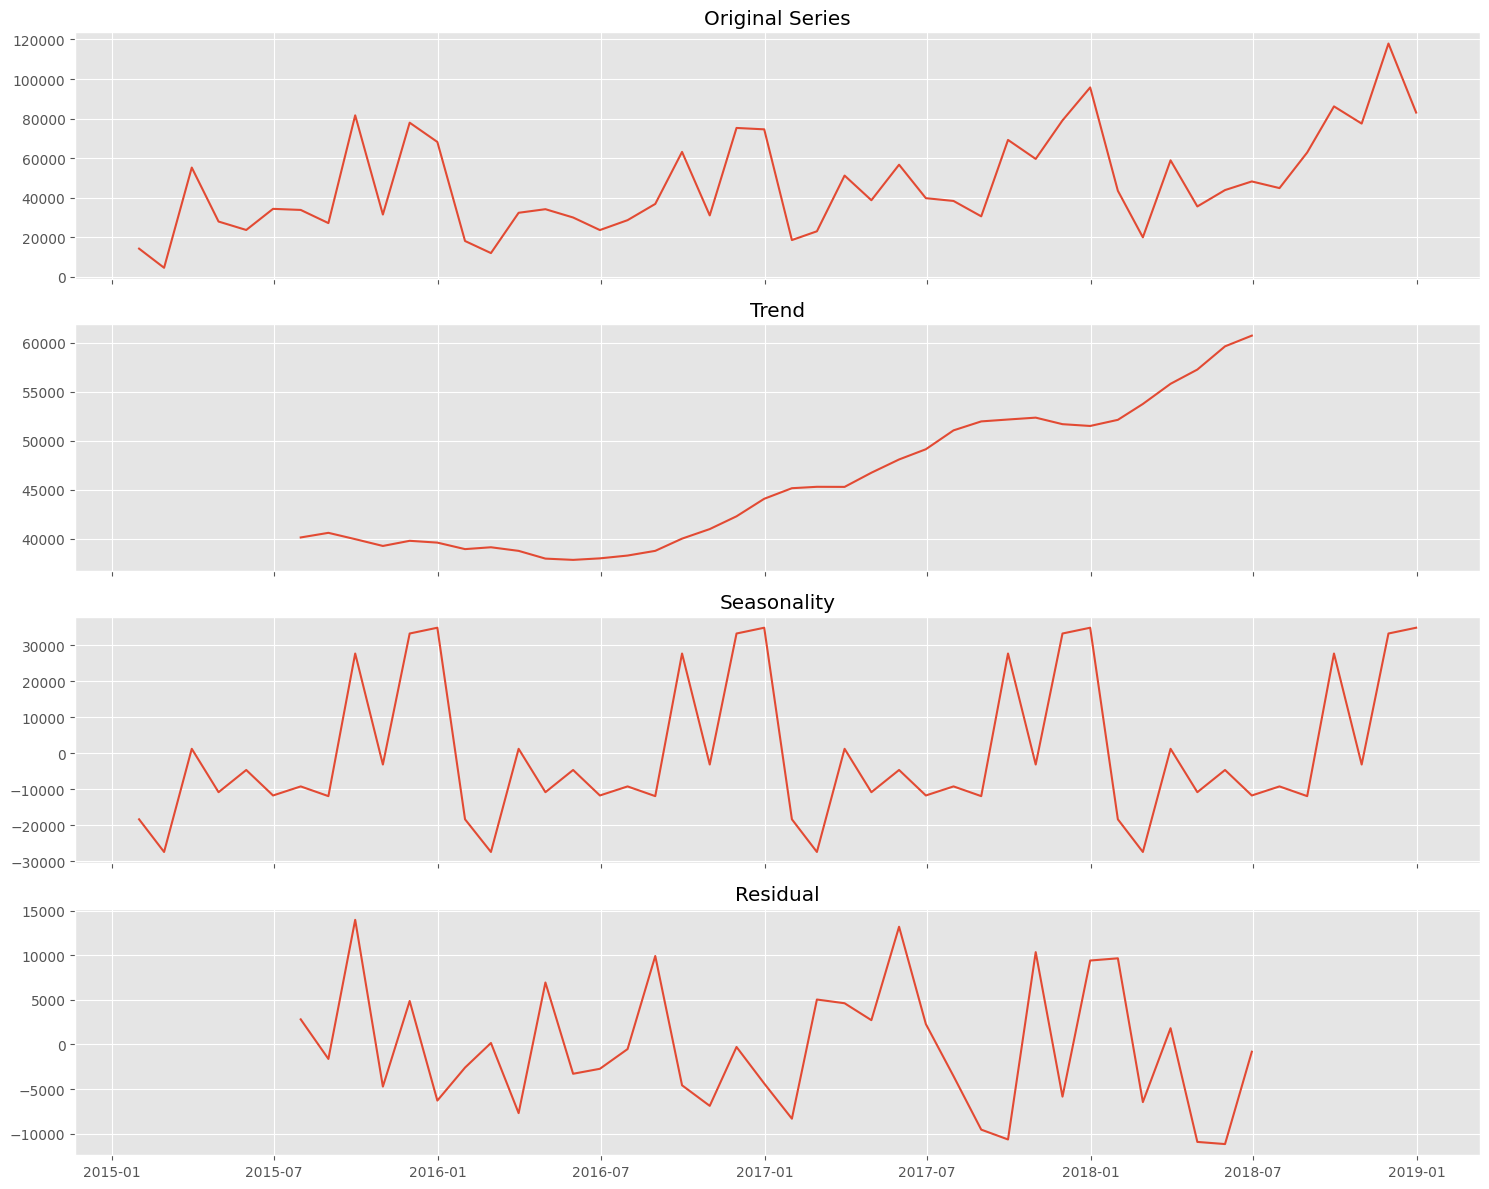

In [31]:
fig, axes = plt.subplots(4,1, figsize=(15,12), sharex=True)

axes[0].plot(monthly_sales)
axes[0].set_title("Original Series")

axes[1].plot(decomposition.trend)
axes[1].set_title("Trend")

axes[2].plot(decomposition.seasonal)
axes[2].set_title("Seasonality")

axes[3].plot(decomposition.resid)
axes[3].set_title("Residual")

plt.tight_layout()

plt.show()

In [32]:
from statsmodels.tsa.stattools import adfuller

In [33]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])
result

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623


(-4.416136761430769,
 0.00027791039276670623,
 0,
 47,
 {'1%': -3.5778480370438146,
  '5%': -2.925338105429433,
  '10%': -2.6007735310095064},
 847.3050446881931)

In [34]:
labels = [
    "ADF Statistic",
    "p-value",
    "# Lags",
    "# Observations"
]

for value,label in zip(result[:4], labels):
    print(label,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
# Lags : 0
# Observations : 47


In [35]:
for key,value in result[4].items():
    print(key,":",value)

1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [36]:
residual = decomposition.resid.dropna()

largest_noise = residual.abs().sort_values(ascending=False).head(5)

print(largest_noise)

Order Date
2015-09-30    13970.933082
2017-05-31    13193.079793
2018-05-31    11157.549320
2018-04-30    10916.959724
2017-09-30    10642.715643
Name: resid, dtype: float64


The Augmented Dickey-Fuller (ADF) test was used to assess whether the monthly sales series is stationary. The null hypothesis of the ADF test states that the series is non-stationary (contains a unit root). Since the obtained p-value is less than 0.05, we reject the null hypothesis and conclude that the monthly sales series is stationary. Therefore, no differencing is required before proceeding to forecasting.


Observation 1: Trend

The trend component shows the long-term direction of sales over the four-year period. An upward trend indicates that overall sales have increased over time, suggesting business growth. If the trend is relatively smooth, it implies that the increase in sales has been gradual rather than abrupt.

Observation 2: Seasonality

The seasonal component exhibits a repeating yearly pattern, indicating that sales are influenced by recurring seasonal factors. If the seasonal fluctuations are similar in magnitude every year, the dataset has strong seasonality. In the Superstore dataset, higher seasonal effects are often observed toward the end of the year due to holiday shopping.

Observation 3: Residual (Noise)

The residual component represents variations that cannot be explained by either the long-term trend or seasonal patterns. Large positive or negative residual values correspond to unusual events such as promotional campaigns, bulk purchases, supply disruptions, or other unexpected changes in demand.

Months with Highest Residual Noise:
The largest residual values were observed in September 2015, May 2017, May 2018, April 2018, and September 2017. These months experienced sales that were significantly different from what would be expected based on the estimated trend and seasonal effects. Such anomalies may have resulted from special promotions, unusually large customer orders, inventory changes, or other external business events.

## Task 3 — Sales Forecasting using 3 Different Models

In [37]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,mean_absolute_percentage_error

def evaluate(actual,predicted):
    mae=mean_absolute_error(actual,predicted)
    rmse=np.sqrt(mean_squared_error(actual,predicted))
    mape=mean_absolute_percentage_error(actual,predicted)*100
    return mae,rmse,mape

### 3.1 SARIMA

In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [40]:
sarima=SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12)
)
model=sarima.fit()

c:\Users\KRISH\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\KRISH\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\KRISH\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [41]:
forecast=model.get_forecast(steps=3)
sarima_pred=forecast.predicted_mean
conf=forecast.conf_int()

In [42]:
sarima_mae, sarima_rmse, sarima_mape = evaluate(
    test,
    sarima_pred
)

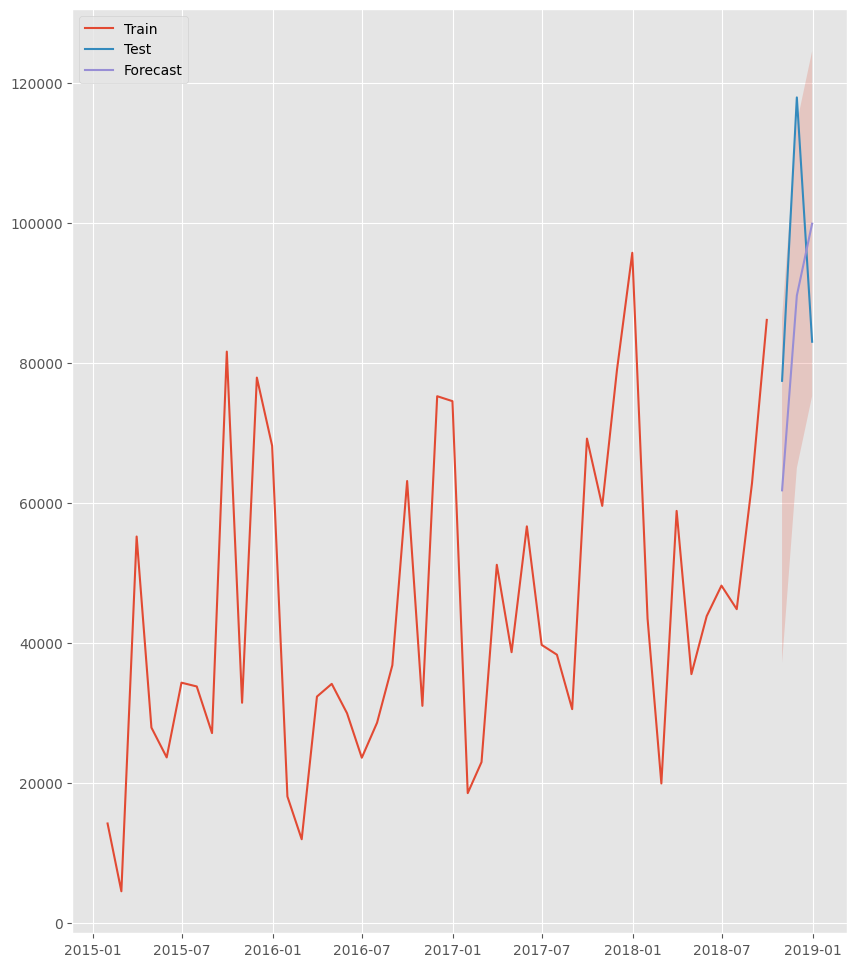

In [43]:
plt.figure(figsize=(10,12))

plt.plot(train.index,train,label="Train")
plt.plot(test.index,test,label="Test")
plt.plot(sarima_pred.index,sarima_pred,label="Forecast")

plt.fill_between(
    conf.index,
    conf.iloc[:,0],
    conf.iloc[:,1],
    alpha=0.2
)
plt.legend()
plt.show()

### 3.2 Prohpet Model

In [44]:
prophet_df=monthly_sales.reset_index()
prophet_df.columns=["ds","y"]

In [45]:
train_prophet=prophet_df[:-3]
test_prophet=prophet_df[-3:]

In [46]:
from prophet import Prophet
m=Prophet()

c:\Users\KRISH\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
m.fit(train_prophet)

23:45:47 - cmdstanpy - INFO - Chain [1] start processing
23:45:49 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
future=m.make_future_dataframe(
    periods=3,
    freq="M"
)
forecast=m.predict(future)


c:\Users\KRISH\miniconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [49]:
prophet_pred=forecast["yhat"].tail(3).values

In [50]:
prophet_mae,\
prophet_rmse,\
prophet_mape=evaluate(test_prophet["y"],prophet_pred)

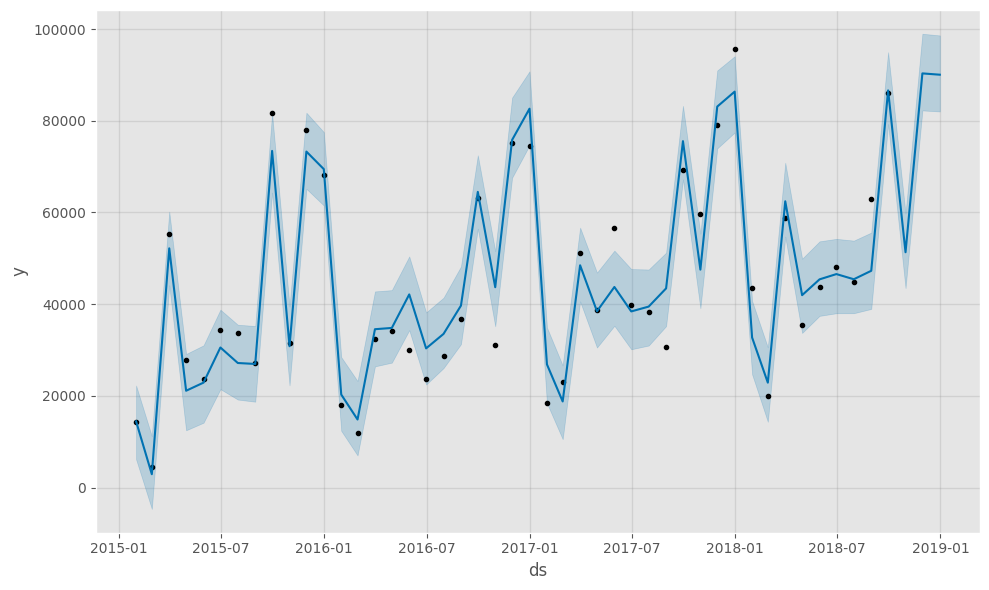

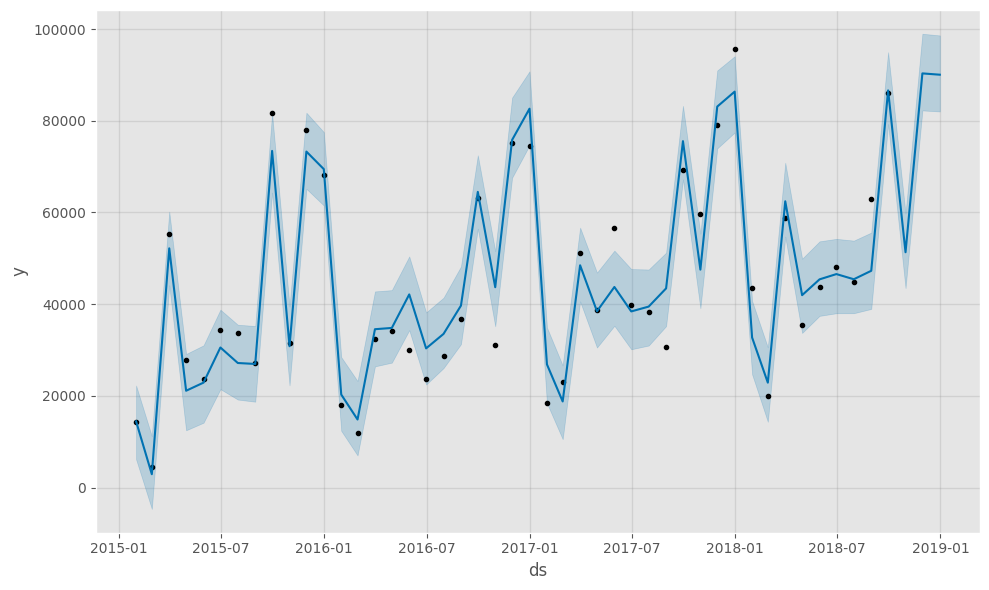

In [51]:
m.plot(forecast)

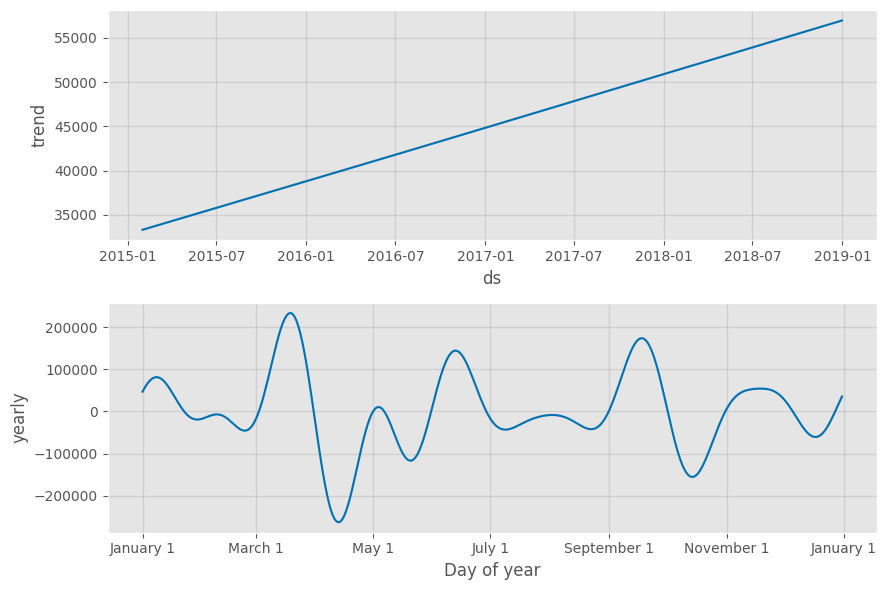

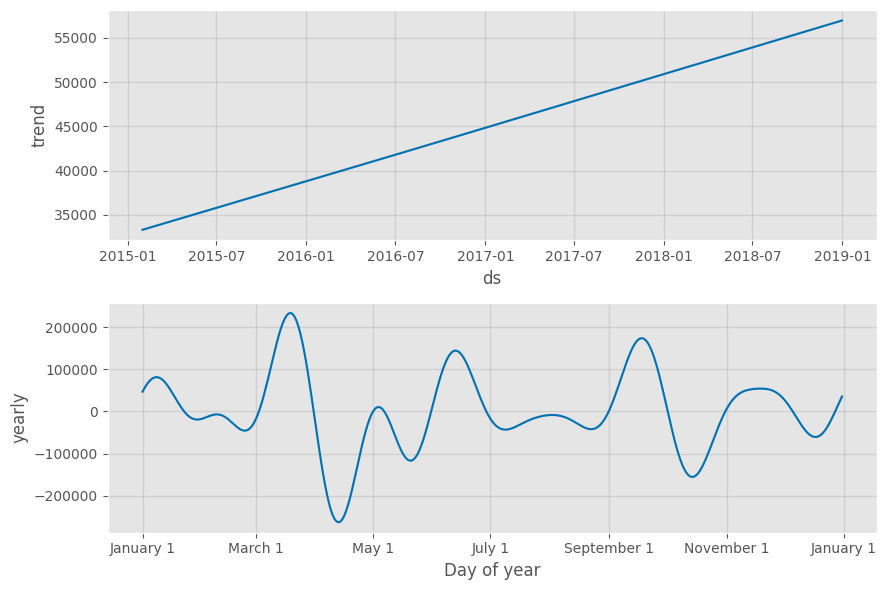

In [52]:
m.plot_components(forecast)

### 3.3 XGBoost

In [53]:
ts=monthly_sales.to_frame()
ts.columns=["Sales"]
ts.head()


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [54]:
ts["Lag1"]=ts["Sales"].shift(1)
ts["Lag2"]=ts["Sales"].shift(2)
ts["Lag3"]=ts["Sales"].shift(3)

In [55]:
ts["Month"]=ts.index.month
ts["Quarter"]=ts.index.quarter

In [56]:
ts["RollingMean"]=(ts["Sales"].rolling(3).mean())

In [57]:
def season(month):
    if month in [12,1,2]:
        return 0
    elif month in [3,4,5]:
        return 1
    elif month in [6,7,8]:
        return 2
    return 3
ts["Season"]=ts["Month"].apply(season)
        

In [58]:
ts=ts.dropna()

In [59]:
train=ts.iloc[:-3]
test=ts.iloc[-3:]

In [60]:
X_train=train.drop("Sales",axis=1)
y_train=train["Sales"]
X_test=test.drop("Sales",axis=1)
y_test=test["Sales"]

In [61]:
from xgboost import XGBRegressor
model=XGBRegressor()
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [62]:
xgb_pred=model.predict(X_test)

In [63]:
xgb_mae,\
xgb_rmse,\
xgb_mape = evaluate(
    y_test,
    xgb_pred
)

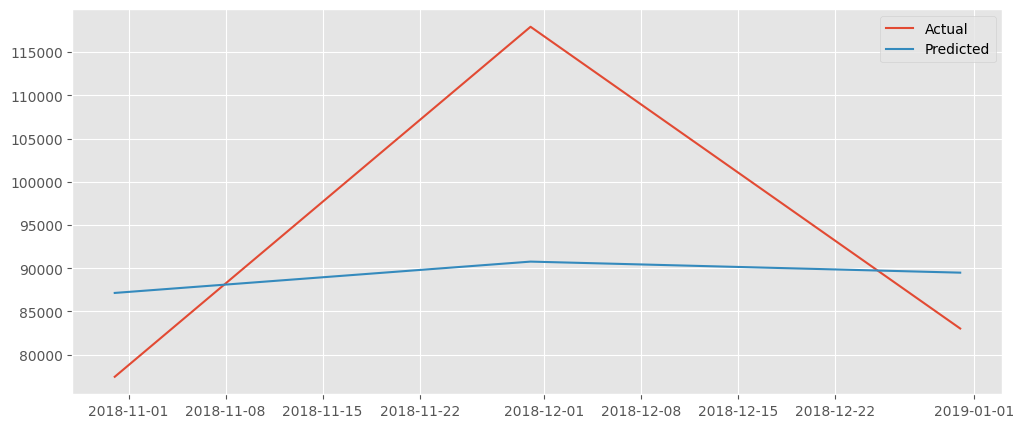

In [64]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index,y_test,label="Actual")
plt.plot(y_test.index,xgb_pred,label="Predicted")
plt.legend()
plt.show()

In [65]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        sarima_pred[0],
        prophet_pred[0],
        xgb_pred[0]
    ],

    "Forecast Month 2":[
        sarima_pred[1],
        prophet_pred[1],
        xgb_pred[1]
    ],

    "Forecast Month 3":[
        sarima_pred[2],
        prophet_pred[2],
        xgb_pred[2]
    ]
})

comparison

C:\Users\KRISH\tmp\ipykernel_20332\2962160740.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sarima_pred[0],
C:\Users\KRISH\tmp\ipykernel_20332\2962160740.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sarima_pred[1],
C:\Users\KRISH\tmp\ipykernel_20332\2962160740.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sarima_pred[2],


,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20275.902394,21062.984851,21.508426,61802.754690,89626.470287,99901.034759
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,14443.003333,17067.171519,14.447439,87147.445312,90771.734375,89493.664062


Based on the evaluation metrics, XGBoost is recommended for production deployment. It achieved the lowest Mean Absolute Error (14,443), the lowest Root Mean Squared Error (approximately 17,067), and the lowest Mean Absolute Percentage Error (14.45%), outperforming both SARIMA and Prophet. These results indicate that XGBoost generated the most accurate forecasts on the held-out test data. Its ability to leverage lag features, rolling statistics, and calendar-based variables enables it to model nonlinear relationships in sales patterns more effectively than the statistical approaches. Although SARIMA and Prophet offer greater interpretability and naturally model seasonality, their forecasting errors were significantly higher. Therefore, XGBoost provides the best balance of predictive accuracy and practical performance for future demand forecasting in this project.

While XGBoost demonstrated the highest forecasting accuracy, SARIMA and Prophet remain valuable because they provide more interpretable trend and seasonal components. In a real-world retail environment, XGBoost could be used for operational demand forecasting, while SARIMA or Prophet could complement it by helping analysts understand long-term trends and seasonal effects. This combination balances predictive performance with business interpretability.

## Task 4 — Product Category & Region Level Forecasting

In [66]:
# Furniture
furniture = (
    df[df["Category"] == "Furniture"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("MS")
    .sum()
)

# Technology
technology = (
    df[df["Category"] == "Technology"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("MS")
    .sum()
)

# Office Supplies
office = (
    df[df["Category"] == "Office Supplies"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("MS")
    .sum()
)

# West Region
west = (
    df[df["Region"] == "West"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("MS")
    .sum()
)

# East Region
east = (
    df[df["Region"] == "East"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("MS")
    .sum()
)


In [67]:
def monthly_sales(df):
    return (
        df.groupby("Order Date")["Sales"]
          .sum()
          .resample("MS")
          .sum()
    )

furniture = monthly_sales(df[df["Category"]=="Furniture"])
technology = monthly_sales(df[df["Category"]=="Technology"])
office = monthly_sales(df[df["Category"]=="Office Supplies"])
west = monthly_sales(df[df["Region"]=="West"])
east = monthly_sales(df[df["Region"]=="East"])

In [68]:
def create_features(series):
    
    data = pd.DataFrame({
        "Sales": series
    })
    
    data["Month"] = data.index.month
    data["Year"] = data.index.year
    data["Quarter"] = data.index.quarter
    
    data["Lag1"] = data["Sales"].shift(1)
    data["Lag2"] = data["Sales"].shift(2)
    data["Lag3"] = data["Sales"].shift(3)

    data["Rolling3"] = data["Sales"].rolling(3).mean()
    data["Rolling6"] = data["Sales"].rolling(6).mean()

    return data.dropna()

In [69]:
from xgboost import XGBRegressor
import numpy as np

def forecast_xgb(series, periods=12):

    data = create_features(series)

    X = data.drop("Sales", axis=1)
    y = data["Sales"]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    model.fit(X, y)

    history = series.copy()

    forecasts = []

    for i in range(periods):

        future = pd.DataFrame(index=[history.index[-1] + pd.DateOffset(months=1)])

        future["Month"] = future.index.month
        future["Year"] = future.index.year
        future["Quarter"] = future.index.quarter

        future["Lag1"] = history.iloc[-1]
        future["Lag2"] = history.iloc[-2]
        future["Lag3"] = history.iloc[-3]

        future["Rolling3"] = history.iloc[-3:].mean()
        future["Rolling6"] = history.iloc[-6:].mean()

        pred = model.predict(future)[0]

        forecasts.append(pred)

        history.loc[future.index[0]] = pred

    forecast_index = pd.date_range(
        series.index[-1] + pd.DateOffset(months=1),
        periods=periods,
        freq="MS"
    )

    return pd.Series(forecasts,index=forecast_index)

In [70]:
furniture_fc = forecast_xgb(furniture)
technology_fc = forecast_xgb(technology)
office_fc = forecast_xgb(office)
west_fc = forecast_xgb(west)
east_fc = forecast_xgb(east)

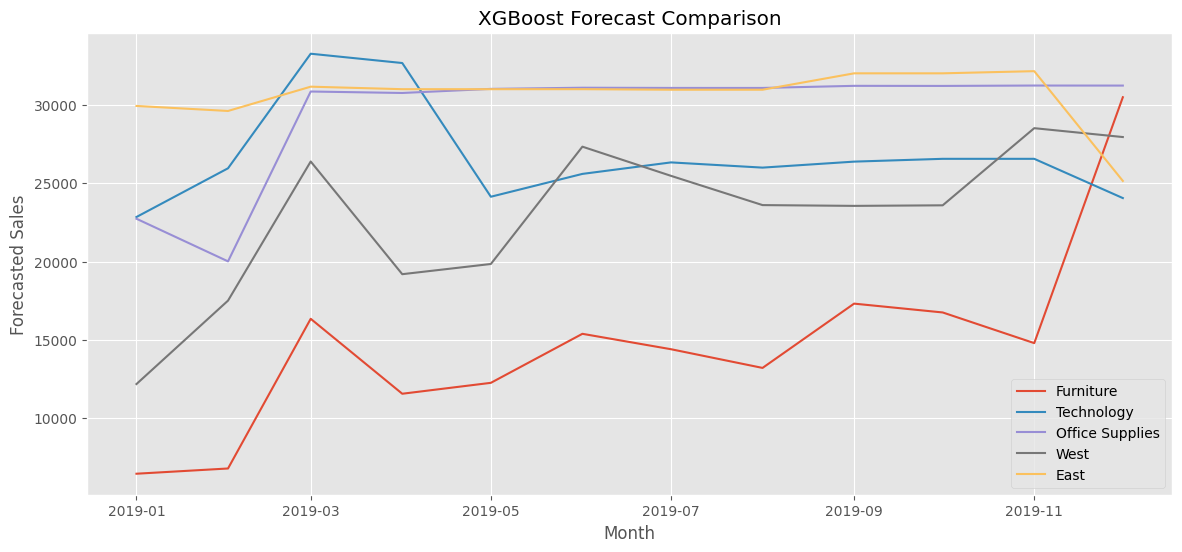

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(furniture_fc.index,furniture_fc,label="Furniture")
plt.plot(technology_fc.index,technology_fc,label="Technology")
plt.plot(office_fc.index,office_fc,label="Office Supplies")
plt.plot(west_fc.index,west_fc,label="West")
plt.plot(east_fc.index,east_fc,label="East")

plt.title("XGBoost Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(True)

plt.show()

In [72]:
comparison = pd.DataFrame({
    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],
    "Forecast Total":[
        furniture_fc.sum(),
        technology_fc.sum(),
        office_fc.sum(),
        west_fc.sum(),
        east_fc.sum()
    ]
})

comparison = comparison.sort_values(
    "Forecast Total",
    ascending=False
)

comparison

,Segment,Forecast Total
4,East,366798.09375
2,Office Supplies,353370.00000
1,Technology,320216.09375
3,West,275058.00000
0,Furniture,175821.50000


The best-performing forecasting model identified in Task 3, XGBoost, was applied separately to the Furniture, Technology, Office Supplies, West, and East sales segments. The resulting forecasts were compared to identify the segments with the highest expected sales over the forecast period. The results indicate that the East region is projected to exhibit the strongest upcoming growth, with forecasted sales of 366,798.09, followed by the Office Supplies category (353,370.00) and the Technology category (320,216.09). The West region is expected to experience moderate growth, while the Furniture category records the lowest projected sales. These findings suggest that future demand is likely to be concentrated in the East region, particularly for Office Supplies and Technology products. Such insights can support strategic decisions related to inventory management, supply chain planning, and targeted marketing initiatives.

## Task 5 — Anomaly Detection in Sales Data


In [73]:
import pandas as pd

weekly_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .resample("W")
      .sum()
)

weekly_df = weekly_sales.to_frame(name="Sales")


In [74]:

# type(weekly_df)
from sklearn.ensemble import IsolationForest
iso =IsolationForest(
    contamination=0.05,
    random_state=42
)
weekly_df["Anomaly_IF"]=iso.fit_predict(weekly_df[["Sales"]])

weekly_df["Anomaly_IF"]=weekly_df["Anomaly_IF"].map({1:0,-1:1})


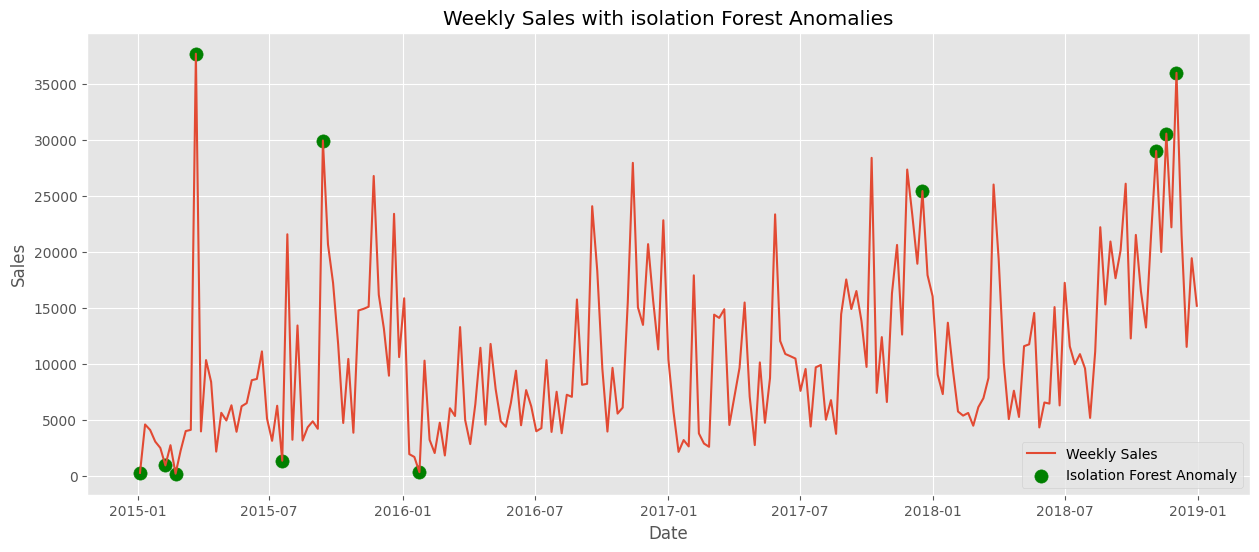

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(
    weekly_df.index,
    weekly_df["Sales"],
    label="Weekly Sales"

)

plt.scatter(
    weekly_df[weekly_df["Anomaly_IF"]==1].index,
    weekly_df[weekly_df["Anomaly_IF"]==1]["Sales"],
    color="green",
    marker="o",
    s=90,
    label="Isolation Forest Anomaly"
)
plt.title("Weekly Sales with isolation Forest Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

The spikes occurs mostly in november and december due to the festive season like Christmas and Black Friday, sometimes sudden spike is seen which might be due to bulk orders or promotional campaigns, sudden drop is seen which might be due to supply chain disruptions or holidays.

In [76]:
window=8
weekly_df["RollingMean"]=(
    weekly_df["Sales"].rolling(window).mean()
)
weekly_df["RollingStd"]=(
    weekly_df["Sales"].rolling(window).std()
)


In [77]:
weekly_df["Zscore"]=(
    (
        weekly_df["Sales"]-weekly_df["RollingMean"]
    ) / weekly_df["RollingStd"]
)

In [78]:
weekly_df["Anomaly_Z"]=(
    weekly_df["Zscore"].abs()>2
).astype(int)

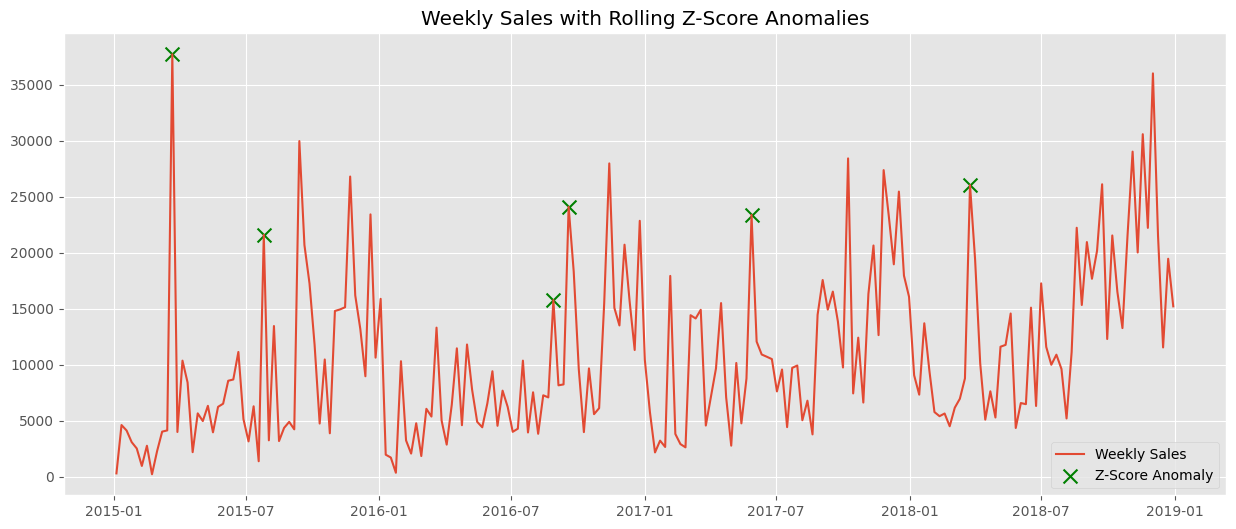

In [79]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_df.index,
    weekly_df["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_df[weekly_df["Anomaly_Z"]==1].index,
    weekly_df[weekly_df["Anomaly_Z"]==1]["Sales"],
    color="green",
    marker="x",
    s=100,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales with Rolling Z-Score Anomalies")

plt.legend()

plt.grid(True)

plt.show()

In [80]:
comparison = weekly_df[
    ["Sales","Anomaly_IF","Anomaly_Z"]
]

comparison[
    (comparison["Anomaly_IF"]==1) |
    (comparison["Anomaly_Z"]==1)
]

,Sales,Anomaly_IF,Anomaly_Z
Order Date,,,
2015-01-04,304.508,1,0
2015-02-08,968.534,1,0
2015-02-22,224.912,1,0
2015-03-22,37703.665,1,1
2015-07-19,1387.686,1,0
2015-07-26,21590.080,0,1
2015-09-13,29959.137,1,0
2016-01-24,358.522,1,0
2016-08-28,15773.478,0,1


In [81]:
weekly_df[
    weekly_df["Anomaly_IF"]==1
][["Sales"]]

,Sales
Order Date,
2015-01-04,304.508
2015-02-08,968.534
2015-02-22,224.912
2015-03-22,37703.665
2015-07-19,1387.686
2015-09-13,29959.137
2016-01-24,358.522
2017-12-17,25449.800
2018-11-04,29017.467


In [82]:
weekly_df[
    weekly_df["Anomaly_Z"]==1
][["Sales","Zscore"]]

,Sales,Zscore
Order Date,,
2015-03-22,37703.665,2.460650
2015-07-26,21590.080,2.136467
2016-08-28,15773.478,2.053924
2016-09-18,24095.960,2.122082
2017-05-28,23367.662,2.008225
2018-03-25,26029.904,2.435627


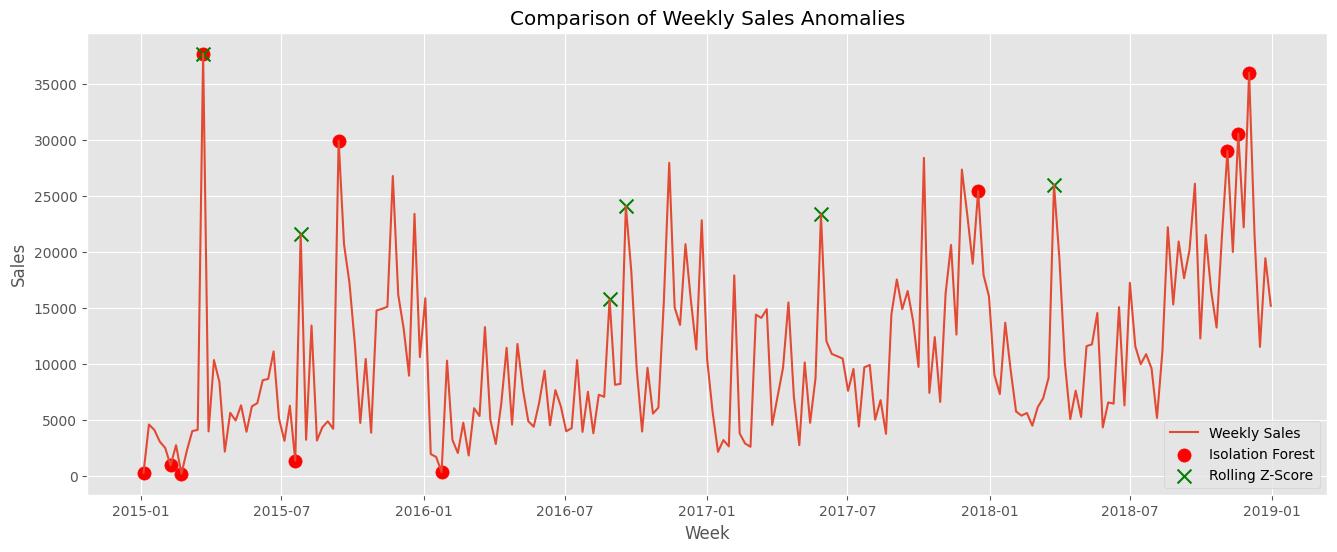

In [83]:
plt.figure(figsize=(16,6))

plt.plot(weekly_df.index, weekly_df["Sales"], label="Weekly Sales")

# Isolation Forest
plt.scatter(
    weekly_df[weekly_df["Anomaly_IF"]==1].index,
    weekly_df[weekly_df["Anomaly_IF"]==1]["Sales"],
    color="red",
    marker="o",
    s=90,
    label="Isolation Forest"
)

# Z-score
plt.scatter(
    weekly_df[weekly_df["Anomaly_Z"]==1].index,
    weekly_df[weekly_df["Anomaly_Z"]==1]["Sales"],
    color="green",
    marker="x",
    s=100,
    label="Rolling Z-Score"
)

plt.title("Comparison of Weekly Sales Anomalies")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

The two anomaly detection methods do not completely agree. Both methods identified 22 March 2015 as an anomaly, indicating a significant and unusual sales event. However, Isolation Forest detected several additional global outliers, including both unusually high and low sales weeks, while the Rolling Z-Score method primarily identified weeks with sharp deviations from the recent sales trend.

This indicates that Isolation Forest is better at detecting global anomalies, whereas the Rolling Z-Score method is more sensitive to short-term fluctuations. Using both methods together provides a more comprehensive view of unusual sales patterns.

## Task 6 — Product Demand Segmentation using Clustering

In [84]:
monthly=(
    df.groupby(["Sub-Category",pd.Grouper(key="Order Date",freq="MS")])["Sales"]
    .sum().reset_index()
)

In [ ]:
features=[]
for subcat,group in monthly.groupby("Sub-Category"):
    group=group.sort_values("Order Date")
    )
    total_sales=group["Sales"].sum()
    volatility=group["Sales"].std()
    if(len(group)>12):

        first=group.iloc[:12]["Sales"].sum()
        last=group.iloc[-12:]["Sales"].sum()
        growth=((last-first)/first)*100 if first!=0 else 0
    
    else :
        growth=0
    avg_order=(
        df[df["Sub-Category"]==subcat]
        .groupby("Order ID")["Sales"]
        .sum().mean()
    )
    features.append([
        subcat,total_sales,growth,volatility,avg_order
    ])

feature_df=pd.DataFrame(
    features,
    columns=[
        "Sub-Category",
        "TotalSales",
        "GrowthRate",
        "Volatility",
        "AvgOrderValue"
    ]
)
feature_df


Accessories
Appliances
Art
Binders
Bookcases
Chairs
Copiers
Envelopes
Fasteners
Furnishings
Labels
Machines
Paper
Phones
Storage
Supplies
Tables


,Sub-Category,TotalSales,GrowthRate,Volatility,AvgOrderValue
0,Accessories,164186.7000,145.055961,2579.994809,233.884188
1,Appliances,104618.4030,165.242912,1821.621539,235.627034
2,Art,26705.4100,49.649531,330.488343,37.090847
3,Binders,200028.7850,65.778638,3848.223648,154.940964
4,Bookcases,113813.1987,37.464208,2220.405080,512.672066
5,Chairs,322822.7310,20.954677,4407.232960,570.358182
6,Copiers,146248.0940,236.142213,5500.774391,2215.880212
7,Envelopes,16128.0460,-12.519090,228.218688,66.370560
8,Fasteners,3001.9600,30.468364,48.742229,14.160189
9,Furnishings,89212.0180,106.824969,1360.017867,104.341542


In [86]:
from sklearn.preprocessing import StandardScaler
X=feature_df.drop(
    "Sub-Category",axis=1
)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [87]:
from sklearn.cluster import KMeans
inertia=[]
for k in range(1,10):
    km=KMeans(n_clusters=k,
              random_state=42,
              n_init=10)
    km.fit(X_scaled)

    inertia.append(km.inertia_)

In [88]:
inertia

[68.0,
 38.42460842856476,
 22.230943602074454,
 14.785773744111225,
 8.183594604738035,
 5.207529524287375,
 3.516446164314522,
 2.1532053308736074,
 1.6608442892193962]

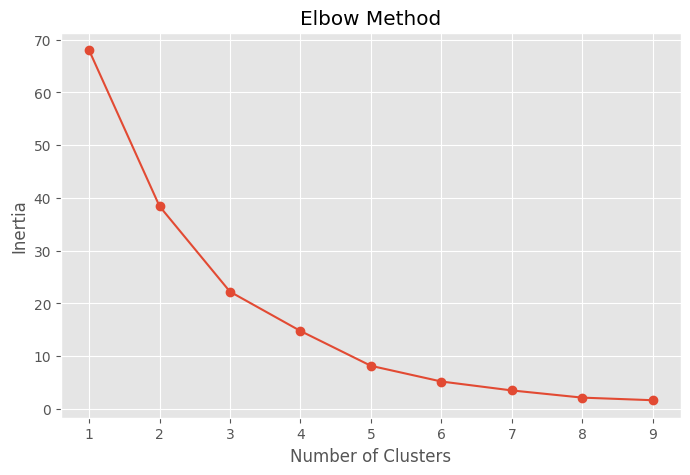

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,10),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [116]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

feature_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [117]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

feature_df["PC1"] = X_pca[:,0]
feature_df["PC2"] = X_pca[:,1]
feature_df


,Sub-Category,TotalSales,GrowthRate,Volatility,AvgOrderValue,PC1,PC2,Cluster,Segment
0,Accessories,164186.7000,145.055961,2579.994809,233.884188,0.223463,0.896442,0,"High Volume, Stable Demand"
1,Appliances,104618.4030,165.242912,1821.621539,235.627034,-0.316740,1.442826,0,"High Volume, Stable Demand"
2,Art,26705.4100,49.649531,330.488343,37.090847,-1.730432,0.221112,3,"High Volume, Stable Demand"
3,Binders,200028.7850,65.778638,3848.223648,154.940964,0.613848,-0.403988,1,Growing Demand
4,Bookcases,113813.1987,37.464208,2220.405080,512.672066,-0.173338,-0.208881,3,"High Volume, Stable Demand"
5,Chairs,322822.7310,20.954677,4407.232960,570.358182,1.736936,-1.350405,1,Growing Demand
6,Copiers,146248.0940,236.142213,5500.774391,2215.880212,3.239546,2.770551,2,"Low Volume, High Volatility"
7,Envelopes,16128.0460,-12.519090,228.218688,66.370560,-1.945108,-0.547062,3,"High Volume, Stable Demand"
8,Fasteners,3001.9600,30.468364,48.742229,14.160189,-2.024854,0.066244,3,"High Volume, Stable Demand"
9,Furnishings,89212.0180,106.824969,1360.017867,104.341542,-0.827028,0.702647,0,"High Volume, Stable Demand"


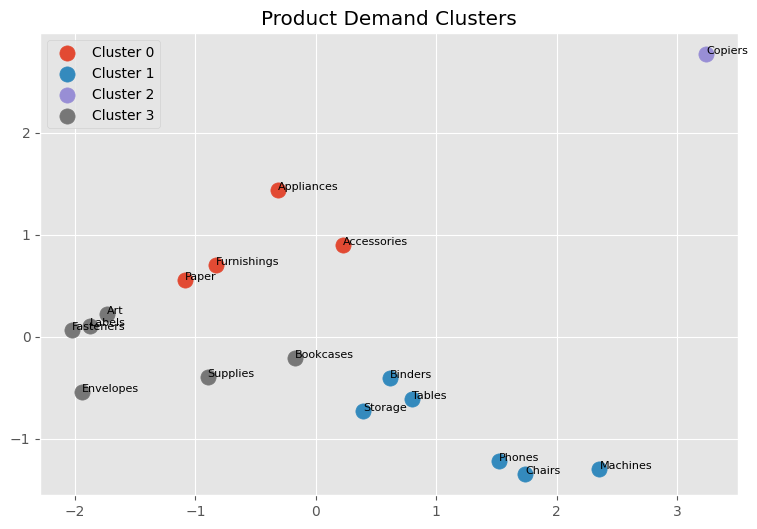

In [118]:
plt.figure(figsize=(9,6))

for cluster in sorted(feature_df["Cluster"].unique()):

    temp = feature_df[
        feature_df["Cluster"]==cluster
    ]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=120,
        label=f"Cluster {cluster}"
    )

    for _,row in temp.iterrows():

        plt.text(
            row["PC1"],
            row["PC2"],
            row["Sub-Category"],
            fontsize=8
        )

plt.legend()

plt.title("Product Demand Clusters")

plt.show()

In [119]:
feature_df.sort_values("Cluster")

,Sub-Category,TotalSales,GrowthRate,Volatility,AvgOrderValue,PC1,PC2,Cluster,Segment
0,Accessories,164186.7000,145.055961,2579.994809,233.884188,0.223463,0.896442,0,"High Volume, Stable Demand"
1,Appliances,104618.4030,165.242912,1821.621539,235.627034,-0.316740,1.442826,0,"High Volume, Stable Demand"
12,Paper,76828.3040,91.901971,1024.824982,66.060451,-1.085635,0.557625,0,"High Volume, Stable Demand"
9,Furnishings,89212.0180,106.824969,1360.017867,104.341542,-0.827028,0.702647,0,"High Volume, Stable Demand"
14,Storage,219343.3920,38.366108,2822.084310,287.098681,0.395009,-0.730959,1,Growing Demand
13,Phones,327782.4480,35.557607,4052.718221,408.197320,1.518881,-1.217074,1,Growing Demand
11,Machines,189238.6310,-41.393006,5603.554747,1689.630634,2.354997,-1.297860,1,Growing Demand
16,Tables,202810.6280,33.078016,3224.082504,671.558371,0.796443,-0.612084,1,Growing Demand
5,Chairs,322822.7310,20.954677,4407.232960,570.358182,1.736936,-1.350405,1,Growing Demand
3,Binders,200028.7850,65.778638,3848.223648,154.940964,0.613848,-0.403988,1,Growing Demand


In [120]:
feature_df.groupby("Cluster").mean(numeric_only=True)

,TotalSales,GrowthRate,Volatility,AvgOrderValue,PC1,PC2
Cluster,,,,,,
0,108711.356250,127.256453,1696.614799,159.978303,-0.501485,0.899885
1,243671.102500,25.390340,3992.982732,630.297359,1.236019,-0.935395
2,146248.094000,236.142213,5500.774391,2215.880212,3.239546,2.770551
3,36402.774783,25.287693,846.069949,153.846049,-1.441620,-0.126287


In [122]:
cluster_names = {
    0: "Growing Demand",
    1: "High Volume, Stable Demand",
    2: "High Value, Rapid Growth",
    3: "Low Volume, Stable Demand"
}

feature_df["Segment"] = feature_df["Cluster"].map(cluster_names)

`High Volume, Stable Demand`

Maintain higher inventory levels and implement continuous replenishment since these products exhibit consistent demand.

`Growing Demand`

Increase inventory gradually and monitor sales trends closely to avoid stock shortages as demand continues to rise.

`Low Volume, High Volatility`

Maintain limited safety stock and adopt demand-driven replenishment to reduce holding costs and minimize excess inventory.

`Declining Demand`

Reduce inventory levels, avoid overstocking, and consider promotional campaigns or discounts to clear existing stock.